
## 📘 About the Dataset

The **Adult Income Dataset** (also called the **Census Income Dataset**) is a well-known benchmark dataset in the machine learning community. It was extracted from the 1994 U.S. Census database and is publicly available through  [Kaggle](https://www.kaggle.com/datasets/wenruliu/adult-income-dataset).

This dataset is commonly used for **binary classification tasks**, where the goal is to **predict whether a person earns more than \$50,000 a year (`>50K`) or not (`<=50K`)** based on a variety of demographic and employment-related attributes.

---

## 📊 Dataset Summary

* **Number of Instances:** \~32,000
* **Number of Features:** 14 (excluding the label)
* **Target Variable:** `income` – Whether income is `<=50K` or `>50K`
* **Task:** Binary Classification

---

## 📑 Dataset Columns (Feature Descriptions)

Here is a detailed description of each feature in the dataset:

| Column Name            | Description                                                                                                          |
| ---------------------- | -------------------------------------------------------------------------------------------------------------------- |
| **1. age**             | Age of the individual (continuous numeric value).                                                                    |
| **2. workclass**       | Type of employer (e.g., Private, Self-employed, Government, etc.).                                                   |
| **3. fnlwgt**          | Final weight – a census-designed feature indicating the number of people the record represents. Often ignored in ML. |
| **4. education**       | Highest level of education attained (e.g., Bachelors, HS-grad, etc.).                                                |
| **5. education-num**   | Numerical encoding of the education level (e.g., Bachelors = 13).                                                    |
| **6. marital-status**  | Marital status (e.g., Never-married, Married-civ-spouse, Divorced, etc.).                                            |
| **7. occupation**      | Type of occupation (e.g., Tech-support, Craft-repair, Sales, etc.).                                                  |
| **8. relationship**    | Relationship status within a family (e.g., Husband, Wife, Own-child, etc.).                                          |
| **9. race**            | Race of the individual (e.g., White, Black, Asian-Pac-Islander, etc.).                                               |
| **10. gender**         | Sex of the individual (`Male` or `Female`).                                                                          |
| **11. capital-gain**   | Income from investment sources other than wages/salary (numeric).                                                    |
| **12. capital-loss**   | Capital loss (amount lost from investment or asset devaluation).                                                     |
| **13. hours-per-week** | Number of hours worked per week.                                                                                     |
| **14. native-country** | Country of origin or nationality.                                                                                    |
| **15. income**         | **Target variable** – Whether the person earns `>50K` or `<=50K`.                                                    |

---



In [254]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"mennaw39haleem","key":"bc6207804e8b3098285b0ef046706717"}'}

In [255]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download wenruliu/adult-income-dataset -q

!unzip -q adult-income-dataset.zip -d adult_income
!ls adult_income

Dataset URL: https://www.kaggle.com/datasets/wenruliu/adult-income-dataset
License(s): unknown
replace adult_income/adult.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
adult.csv


In [302]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [303]:
df=pd.read_csv('/content/adult_income/adult.csv')

In [304]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [305]:
df.shape

(48842, 15)

In [306]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [307]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [308]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [309]:
def column_detailes(df):
  col=[]
  col_Dtype=[]
  unique_values=[]
  nuniques=[]
  for l in df.columns:
    col.append(l)
    col_Dtype.append(df[l].dtype)
    unique_values.append(df[l].unique())
    nuniques.append(df[l].nunique())
  return pd.DataFrame({'column':col,'dtype':col_Dtype,'unique_values':unique_values,'nunique':nuniques})

In [310]:
column_detailes(df)

,column,dtype,unique_values,nunique
0,age,int64,"[25, 38, 28, 44, 18, 34, 29, 63, 24, 55, 65, 3...",74
1,workclass,object,"[Private, Local-gov, ?, Self-emp-not-inc, Fede...",9
2,fnlwgt,int64,"[226802, 89814, 336951, 160323, 103497, 198693...",28523
3,education,object,"[11th, HS-grad, Assoc-acdm, Some-college, 10th...",16
4,educational-num,int64,"[7, 9, 12, 10, 6, 15, 4, 13, 14, 16, 3, 11, 5,...",16
5,marital-status,object,"[Never-married, Married-civ-spouse, Widowed, D...",7
6,occupation,object,"[Machine-op-inspct, Farming-fishing, Protectiv...",15
7,relationship,object,"[Own-child, Husband, Not-in-family, Unmarried,...",6
8,race,object,"[Black, White, Asian-Pac-Islander, Other, Amer...",5
9,gender,object,"[Male, Female]",2


in this data missing data is '?' mark

In [311]:
df['workclass'].unique()

array(['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov',
       'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [312]:
df['native-country'].unique()

array(['United-States', '?', 'Peru', 'Guatemala', 'Mexico',
       'Dominican-Republic', 'Ireland', 'Germany', 'Philippines',
       'Thailand', 'Haiti', 'El-Salvador', 'Puerto-Rico', 'Vietnam',
       'South', 'Columbia', 'Japan', 'India', 'Cambodia', 'Poland',
       'Laos', 'England', 'Cuba', 'Taiwan', 'Italy', 'Canada', 'Portugal',
       'China', 'Nicaragua', 'Honduras', 'Iran', 'Scotland', 'Jamaica',
       'Ecuador', 'Yugoslavia', 'Hungary', 'Hong', 'Greece',
       'Trinadad&Tobago', 'Outlying-US(Guam-USVI-etc)', 'France',
       'Holand-Netherlands'], dtype=object)

In [313]:
df['occupation'].unique()

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv', '?',
       'Other-service', 'Prof-specialty', 'Craft-repair', 'Adm-clerical',
       'Exec-managerial', 'Tech-support', 'Sales', 'Priv-house-serv',
       'Transport-moving', 'Handlers-cleaners', 'Armed-Forces'],
      dtype=object)

In [314]:
for i in df.columns:
  if df[i].dtype=='object':
    if '?' in df[i].unique():
      print(f'Column "{i}":')
      print(df[i].value_counts()['?'])

Column "workclass":
2799
Column "occupation":
2809
Column "native-country":
857


In [315]:
df['occupation']=df['occupation'].apply(lambda x: None if x=='?' else x)

In [316]:
df.dropna(inplace=True)

In [317]:
for i in df.columns:
  if df[i].dtype=='object':
    if '?' in df[i].unique():
      print(f'Column "{i}":')
      print(df[i].value_counts()['?'])

Column "native-country":
811


In [318]:
df.shape

(46033, 15)

In [319]:
df['native-country'].value_counts()

,count
native-country,
United-States,41292
Mexico,903
?,811
Philippines,283
Germany,193
Puerto-Rico,175
Canada,163
India,147
El-Salvador,147


**I will drop rows with '?' in the native country column cause 811 rows will not affect in 46K rows in dataset**

In [320]:
df['native-country']=df['native-country'].apply(lambda x: None if x=='?' else x)

In [321]:
df.dropna(inplace=True)

In [322]:
df.isnull().value_counts().sort_values(ascending=False)

,,,,,,,,,,,,,,,count
age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,
False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,45222


In [323]:
def check_outliers(df):
  """
  Identifies outliers in numerical columns using the IQR method.

  Args:
    df: pandas DataFrame

  Returns:
    A dictionary where keys are column names and values are lists of outlier values.
  """
  outliers = {}
  for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col].tolist()
    if col_outliers:
      outliers[col] = col_outliers
  return outliers

In [324]:
for i in check_outliers(df).keys():
  print(f'{i} : {len(check_outliers(df)[i])}')

age : 269
fnlwgt : 1331
educational-num : 294
capital-gain : 3790
capital-loss : 2140
hours-per-week : 11899


In [325]:
df['hours-per-week'].value_counts()

,count
hours-per-week,
40,21358
50,4094
45,2602
60,2085
35,1776
...,...
79,1
94,1
87,1


In [326]:
def remove_outliers(col):
    df_cleaned = df.copy()
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col]= df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)][col]

    return df[col]

In [327]:
def replace_outliers(col):
  df_cleaned = df.copy()
  Q1 = df_cleaned[col].quantile(0.25)
  Q3 = df_cleaned[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df[col]=df[col].apply(lambda x: lower_bound if x<lower_bound else upper_bound if x>upper_bound else x)

  return df[col]

In [328]:
replace_outliers('hours-per-week')

,hours-per-week
0,40.0
1,50.0
2,40.0
3,40.0
5,32.5
...,...
48837,38.0
48838,40.0
48839,40.0
48840,32.5


In [329]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              45222 non-null  int64  
 1   workclass        45222 non-null  object 
 2   fnlwgt           45222 non-null  int64  
 3   education        45222 non-null  object 
 4   educational-num  45222 non-null  int64  
 5   marital-status   45222 non-null  object 
 6   occupation       45222 non-null  object 
 7   relationship     45222 non-null  object 
 8   race             45222 non-null  object 
 9   gender           45222 non-null  object 
 10  capital-gain     45222 non-null  int64  
 11  capital-loss     45222 non-null  int64  
 12  hours-per-week   45222 non-null  float64
 13  native-country   45222 non-null  object 
 14  income           45222 non-null  object 
dtypes: float64(1), int64(5), object(9)
memory usage: 5.5+ MB


# Encoding

In [330]:
df['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

In [331]:
correlation = df.corr(numeric_only=True)
correlation

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,income
age,1.000000,-0.075792,0.037623,0.079683,0.059351,0.107971,0.237040
fnlwgt,-0.075792,1.000000,-0.041993,-0.004110,-0.004349,-0.023167,-0.007264
educational-num,0.037623,-0.041993,1.000000,0.126907,0.081711,0.177854,0.332800
capital-gain,0.079683,-0.004110,0.126907,1.000000,-0.032102,0.092239,0.221034
capital-loss,0.059351,-0.004349,0.081711,-0.032102,1.000000,0.063484,0.148687
hours-per-week,0.107971,-0.023167,0.177854,0.092239,0.063484,1.000000,0.266916
income,0.237040,-0.007264,0.332800,0.221034,0.148687,0.266916,1.000000


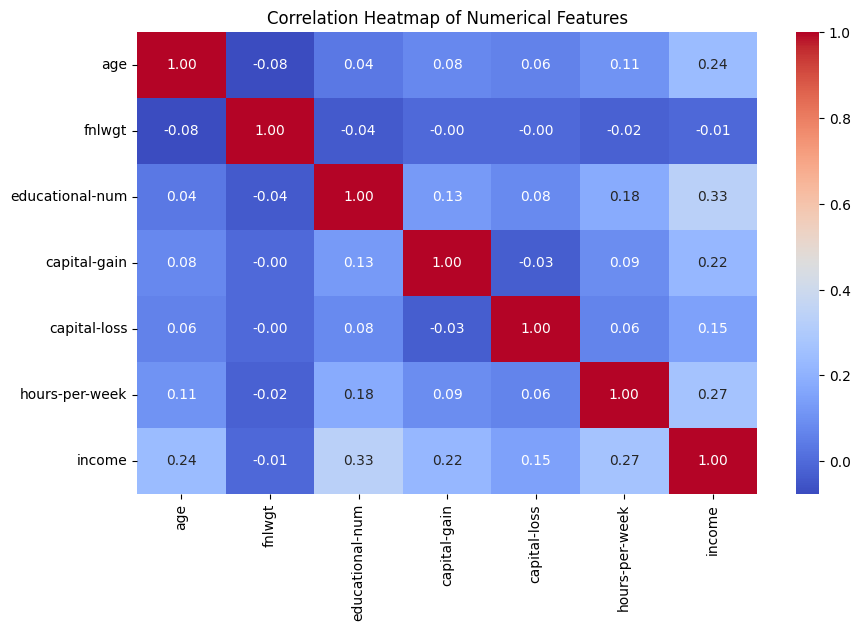

In [332]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


In [333]:
categorical_cols = ['workclass', 'marital-status', 'occupation',
                    'relationship', 'race', 'gender', 'income']
for i in categorical_cols:
  print(df[i].value_counts())

workclass
Private             33307
Self-emp-not-inc     3796
Local-gov            3100
State-gov            1946
Self-emp-inc         1646
Federal-gov          1406
Without-pay            21
Name: count, dtype: int64
marital-status
Married-civ-spouse       21055
Never-married            14598
Divorced                  6297
Separated                 1411
Widowed                   1277
Married-spouse-absent      552
Married-AF-spouse           32
Name: count, dtype: int64
occupation
Craft-repair         6020
Prof-specialty       6008
Exec-managerial      5984
Adm-clerical         5540
Sales                5408
Other-service        4808
Machine-op-inspct    2970
Transport-moving     2316
Handlers-cleaners    2046
Farming-fishing      1480
Tech-support         1420
Protective-serv       976
Priv-house-serv       232
Armed-Forces           14
Name: count, dtype: int64
relationship
Husband           18666
Not-in-family     11702
Own-child          6626
Unmarried          4788
Wife          

In [334]:
# Create a copy to work on
df_cleaned = df.copy()

# 1. Merge workclass categories
df_cleaned['workclass'] = df_cleaned['workclass'].replace({
    'Federal-gov': 'Government',
    'State-gov': 'Government',
    'Local-gov': 'Government',
    'Self-emp-not-inc': 'Self-employed',
    'Self-emp-inc': 'Self-employed',
    'Without-pay': 'Other'
})

# 2. Merge marital-status categories
df_cleaned['marital-status'] = df_cleaned['marital-status'].replace({
    'Married-civ-spouse': 'Married',
    'Married-spouse-absent': 'Previously-married',
    'Married-AF-spouse': 'Previously-married',
    'Divorced': 'Previously-married',
    'Separated': 'Previously-married',
    'Widowed': 'Previously-married'
})

# 3. Merge occupation categories
df_cleaned['occupation'] = df_cleaned['occupation'].replace({
    'Priv-house-serv': 'Other-service',
    'Armed-Forces': 'Other'
})

# 4. Merge relationship categories
df_cleaned['relationship'] = df_cleaned['relationship'].replace({
    'Husband': 'Spouse',
    'Wife': 'Spouse',
    'Other-relative': 'Not-in-family'
})

# 5. Merge race categories
df_cleaned['race'] = df_cleaned['race'].replace({
    'Amer-Indian-Eskimo': 'Other',
    'Other': 'Other'
})

# 6. Drop rows with rare categories (optional)
df_cleaned = df_cleaned[df_cleaned['workclass'] != 'Other']
df_cleaned = df_cleaned[df_cleaned['occupation'] != 'Other']
df=df_cleaned

In [335]:
categorical_cols = ['workclass', 'marital-status', 'occupation',
                    'relationship', 'race', 'gender']


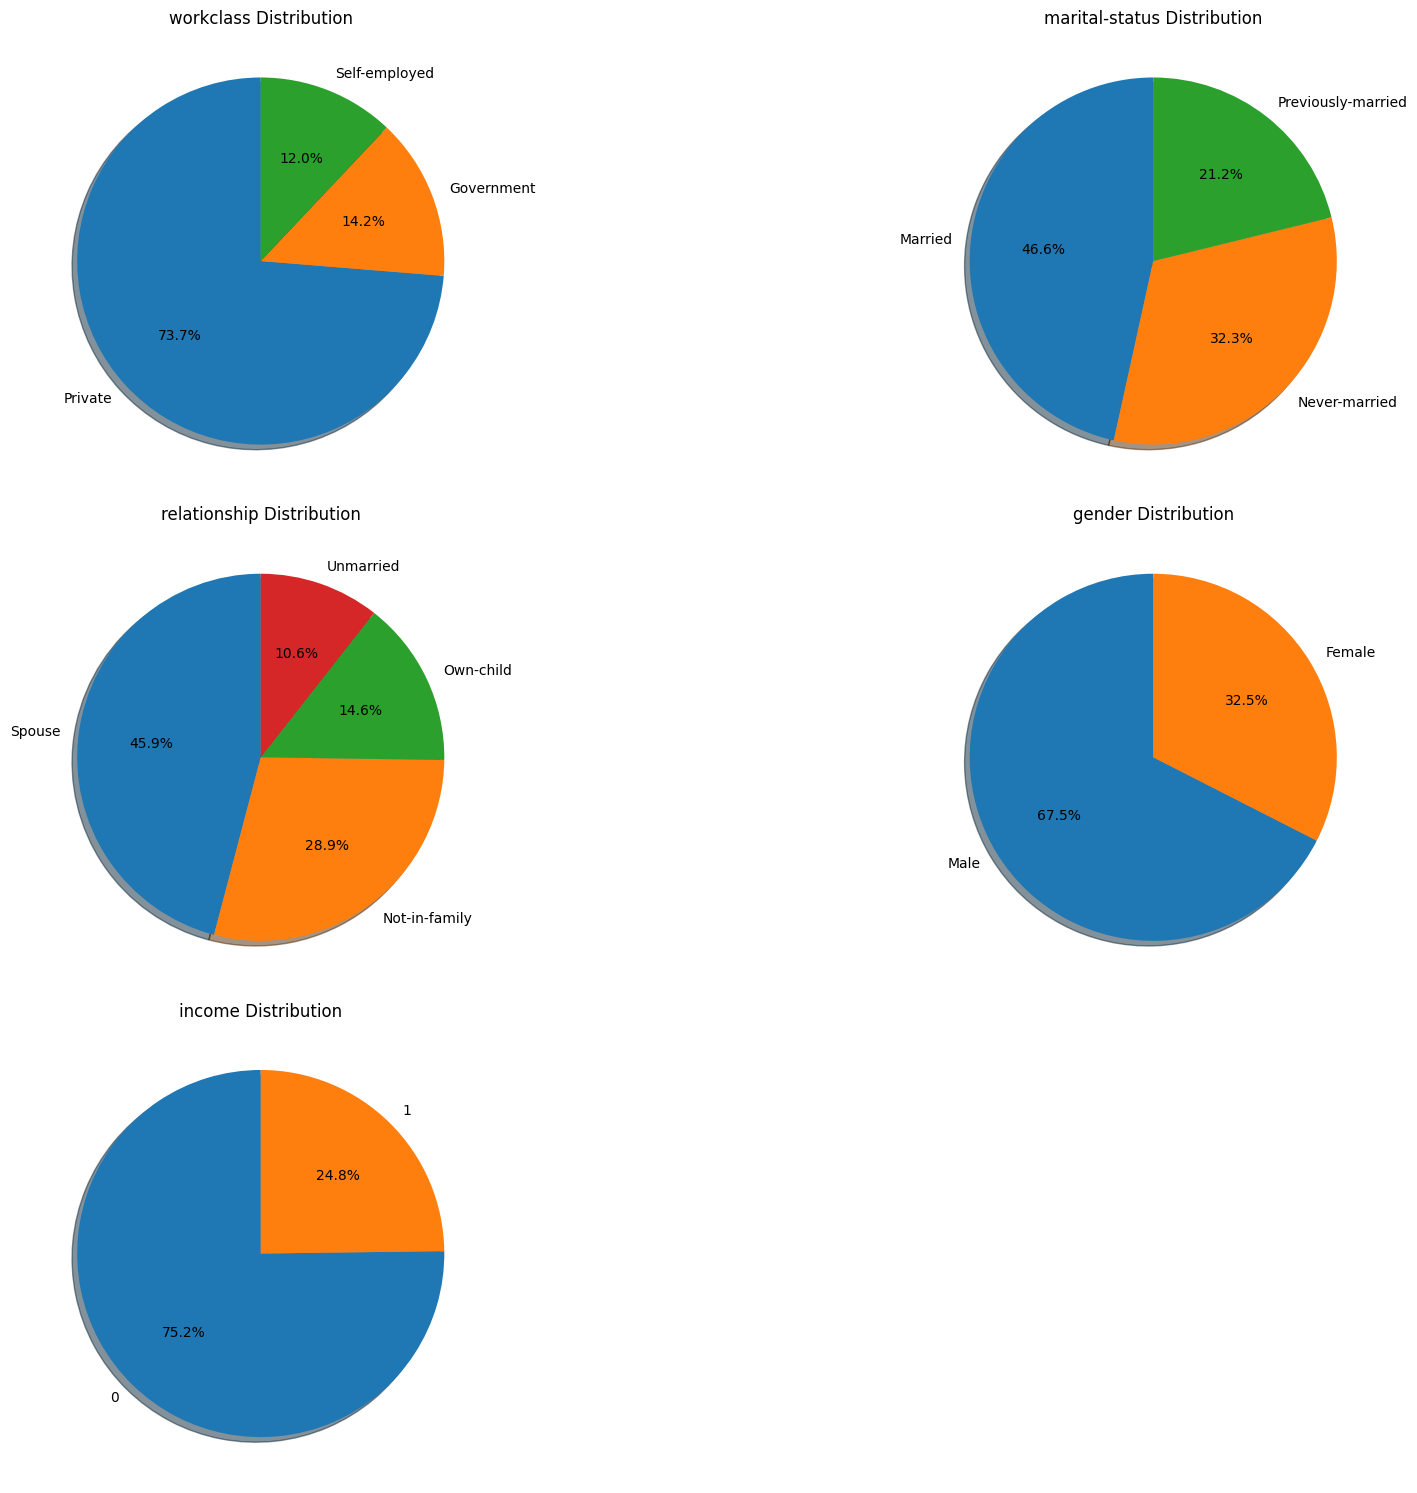

In [336]:
plt.figure(figsize=(18, 20))

categorical_cols = ['workclass', 'marital-status',
                    'relationship', 'gender', 'income']

for i, col in enumerate(categorical_cols):
    plt.subplot(4, 2, i+1)
    df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, shadow=True)
    plt.title(f'{col} Distribution')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [337]:
from sklearn.preprocessing import LabelEncoder

In [338]:
label=LabelEncoder()
cat=df.select_dtypes(include='object').columns
for i in cat:
  df[i]=label.fit_transform(df[i])

In [339]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,1,226802,1,7,1,5,1,1,1,0,0,40.0,38,0
1,38,1,89814,11,9,0,3,2,3,1,0,0,50.0,38,0
2,28,0,336951,7,12,0,8,2,3,1,0,0,40.0,38,1
3,44,1,160323,15,10,0,5,2,1,1,7688,0,40.0,38,1
5,34,1,198693,0,6,1,6,0,3,1,0,0,32.5,38,0


In [340]:
df.drop('fnlwgt',axis=1,inplace=True)

In [341]:
from sklearn.preprocessing import StandardScaler

num_cols = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']


scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [342]:
from sklearn.model_selection import train_test_split
X=df.drop('income',axis=1)
y=df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [343]:
from sklearn.neighbors import KNeighborsClassifier
KNN=KNeighborsClassifier()
KNN.fit(X_train,y_train)

KNeighborsClassifier()

In [344]:
KNN.score(X_test,y_test)

0.8269528656782474

In [345]:
KNN.score(X_train,y_train)

0.8754045755069296

Confusion Matrix:
[[6189  685]
 [ 879 1285]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      6874
           1       0.65      0.59      0.62      2164

    accuracy                           0.83      9038
   macro avg       0.76      0.75      0.75      9038
weighted avg       0.82      0.83      0.82      9038



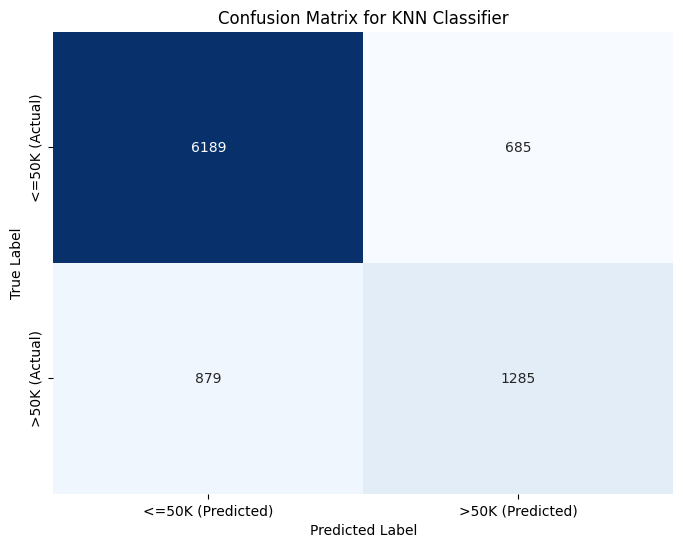

In [346]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict on the test set
y_pred = KNN.predict(X_test)

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Generate the classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

# Optional: Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['<=50K (Predicted)', '>50K (Predicted)'],
            yticklabels=['<=50K (Actual)', '>50K (Actual)'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for KNN Classifier")
plt.show()

# After SMote

Classification Report with balanced income using smote

In [297]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Check class balance after resampling
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_res.value_counts())
X_train=X_train_res
y_train=y_train_res

Before SMOTE:
 income
0    27111
1     9038
Name: count, dtype: int64

After SMOTE:
 income
1    27111
0    27111
Name: count, dtype: int64


Confusion Matrix:
[[5507 1367]
 [ 540 1624]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      6874
           1       0.54      0.75      0.63      2164

    accuracy                           0.79      9038
   macro avg       0.73      0.78      0.74      9038
weighted avg       0.82      0.79      0.80      9038



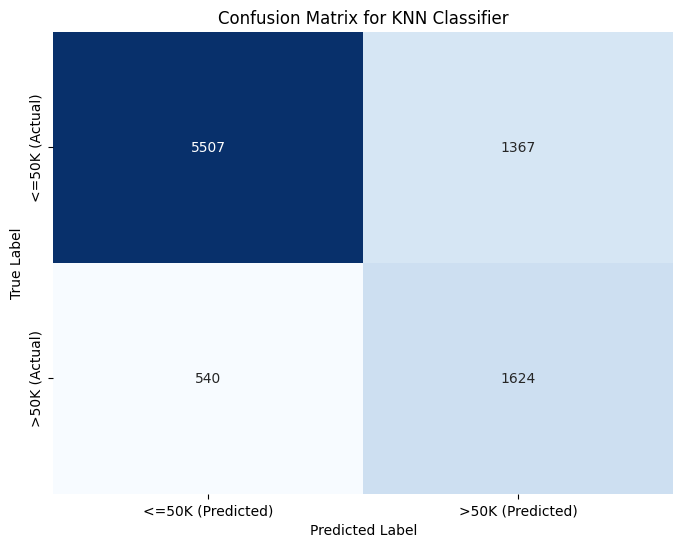

In [301]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict on the test set
y_pred = KNN.predict(X_test)

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Generate the classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

# Optional: Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['<=50K (Predicted)', '>50K (Predicted)'],
            yticklabels=['<=50K (Actual)', '>50K (Actual)'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for KNN Classifier")
plt.show()

# SVM

In [347]:
from sklearn.svm import SVC
svc=SVC()
svc.fit(X_train,y_train)

SVC()

In [348]:
svc.score(X_test,y_test)

0.8363576012392122

In [349]:
svc.score(X_train,y_train)

0.834684223629976

Confusion Matrix:
[[6518  356]
 [1123 1041]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      6874
           1       0.75      0.48      0.58      2164

    accuracy                           0.84      9038
   macro avg       0.80      0.71      0.74      9038
weighted avg       0.83      0.84      0.82      9038



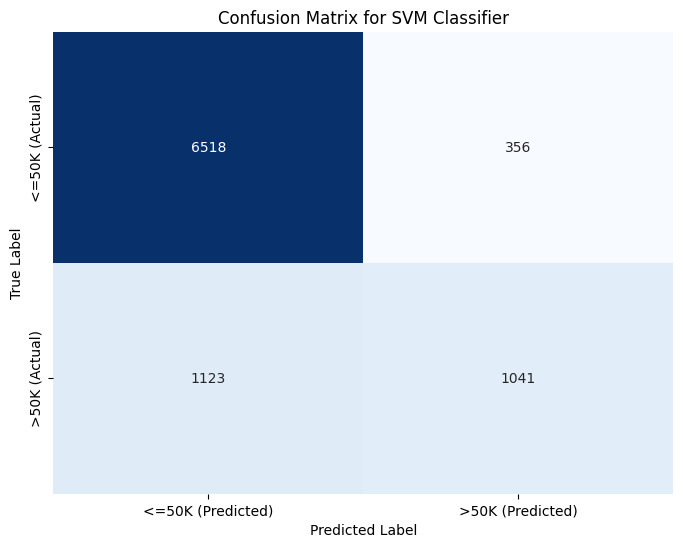

In [350]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict on the test set
y_pred = svc.predict(X_test)

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Generate the classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

# Optional: Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['<=50K (Predicted)', '>50K (Predicted)'],
            yticklabels=['<=50K (Actual)', '>50K (Actual)'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for SVM Classifier")
plt.show()